# 🧠 Machine Learning Ultimate Reference: Part 1
## Chapters 1 - 4: Foundations & Core Data Science Libraries

Welcome to the ultimate, production-grade Machine Learning reference notebook. This notebook covers:
1. **Introduction to AI, ML, DL, GenAI, and Data Science**
2. **Python Revision for Machine Learning**
3. **Complete NumPy Reference (Beginner to Advanced)**
4. **Complete Pandas Reference (Data Manipulation & Analysis)**

---

# 📚 Chapter 1: Introduction to AI, ML, DL, GenAI, and Data Science

## 1.1 The Ecosystem: AI vs. ML vs. DL vs. GenAI vs. Data Science
### Explanation & Analogy
Understanding the distinctions between these terms is critical. They are nested concepts rather than isolated fields:
- **Artificial Intelligence (AI)**: The broadest category. Any technique that enables computers to mimic human intelligence, including rule-based systems (if-then rules).
- **Machine Learning (ML)**: A subset of AI. Algorithms that learn patterns from data without being explicitly programmed.
- **Deep Learning (DL)**: A subset of ML. Uses multi-layered artificial neural networks inspired by the human brain to learn complex representations.
- **Generative AI (GenAI)**: A subset of DL. Focuses on generating *new* content (text, images, code) rather than just classifying or predicting.
- **Data Science (DS)**: An interdisciplinary field that overlaps with all the above, combining programming, math/statistics, domain expertise, and data engineering to extract insights.

```
+-------------------------------------------------------------+
| Data Science (Statistical Analysis, Data Engineering)       |
|  +-------------------------------------------------------+  |
|  | Artificial Intelligence (AI: Expert Systems, Logic)   |  |
|  |  +-------------------------------------------------+  |  |
|  |  | Machine Learning (ML: Regression, Random Forest)|  |  |
|  |  |  +-------------------------------------------+  |  |  |
|  |  |  | Deep Learning (DL: CNNs, RNNs, MLPs)      |  |  |  |
|  |  |  |  +-------------------------------------+  |  |  |  |
|  |  |  |  | Generative AI (LLMs, Diffusion)     |  |  |  |  |
|  |  |  |  +-------------------------------------+  |  |  |  |
|  |  |  +-------------------------------------------+  |  |  |
|  |  +-------------------------------------------------+  |  |
|  +-------------------------------------------------------+  |
+-------------------------------------------------------------+
```

### Real-World Example
- **AI**: An autopilot system that follows deterministic rules.
- **ML**: Spam filtering based on email frequency tables.
- **DL**: Recognizing faces in photos.
- **GenAI**: Writing an article draft using GPT-4.
- **Data Science**: Running customer segmentation analysis to determine market expansion.

### Common Errors & Best Practices
- **Error**: Thinking Deep Learning is always the best tool.
- **Best Practice**: Start with simple ML models (like Logistic Regression) before jumping to neural networks. Simple models are faster, more interpretable, and serve as solid baselines.

### Mini Quiz
1. Which of the following is a subset of Deep Learning?
   - A) AI
   - B) Generative AI (Correct)
   - C) Data Science
2. What makes ML distinct from traditional programming?
   - A) It uses rules instead of data.
   - B) It learns rules from data instead of hardcoding them. (Correct)
   - C) It is faster to compile.

---

## 1.2 History & Key Milestones
- **1950**: Alan Turing proposes the "Turing Test".
- **1956**: Dartmouth Workshop coined the term "Artificial Intelligence".
- **1997**: IBM's Deep Blue defeats chess grandmaster Garry Kasparov.
- **2012**: AlexNet wins ImageNet, triggering the Deep Learning boom.
- **2017**: "Attention Is All You Need" paper introduces the Transformer architecture.
- **2022**: ChatGPT launched, popularizing Generative AI globally.

---

## 1.3 Machine Learning Lifecycle & Pipelines
```
[Define Problem] -> [Data Collection] -> [Data Preprocessing] -> [Model Training] -> [Evaluation] -> [Deployment] -> [Monitoring]
```
A robust machine learning pipeline ensures reproducibility and automates data ingest, cleaning, modeling, and scoring.

### Python Code: A Simple Mock Lifecycle
We generate synthetic data, split it, train a model, evaluate, and predict.



Model trained successfully! Mean Squared Error: 16.3425


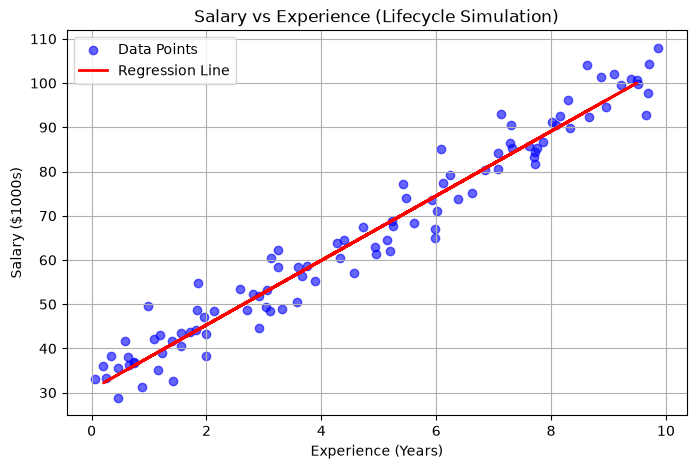

In [8]:
# Chapter 1.3: Simple End-to-End Pipeline
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data (X = Experience in years, y = Salary in $1000s)
np.random.seed(42)
df = pd.read_csv('archive/diabetes.csv')
df = df.fillna
X = np.random.rand(100, 1) * 10  # 0 to 10 years experience
y = 30 + 7.5 * X + np.random.randn(100, 1) * 5  # y = 30 + 7.5*X + noise

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Model trained successfully! Mean Squared Error: {mse:.4f}")

# 5. Visualization
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Data Points')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Salary vs Experience (Lifecycle Simulation)')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary ($1000s)')
plt.legend()
plt.grid(True)
plt.show()



## 1.4 Bias, Variance, Overfitting, Underfitting, and Data Leakage
### Explanation
- **Bias**: Error due to simplistic assumptions in the learning algorithm (underfitting). The model fails to capture the underlying pattern.
- **Variance**: Error due to sensitivity to small fluctuations in the training set (overfitting). The model learns noise as if it were a general pattern.
- **Overfitting**: High training performance, poor test performance.
- **Underfitting**: Poor training performance and poor test performance.
- **Data Leakage**: Information from outside the training dataset is used to create the model, leading to overly optimistic evaluation results.

```
       Underfitting                Ideal Fit                 Overfitting
    (High Bias, Low Var)      (Low Bias, Low Var)       (Low Bias, High Var)
         o      o                   o      o                    o_o
       o   /  o                   o  /  /  o                  / o \       o   / o                    o /  /  o                   o     o o
```

### Preventing Data Leakage
- **Never** fit scalers or preprocessors on the entire dataset. Always split into train and test first, then `.fit()` on train and `.transform()` on both. Or use `sklearn.pipeline.Pipeline`.

### Code: Overfitting vs. Underfitting Visualization



In [ ]:
# Chapter 1.4: Overfitting vs Underfitting
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Generate nonlinear data
X_poly = np.sort(np.random.rand(30) * 10).reshape(-1, 1)
y_poly = np.sin(X_poly).ravel() + np.random.randn(30) * 0.2

# Fit models of degrees 1 (underfit), 3 (ideal), and 15 (overfit)
degrees = [1, 3, 15]
plt.figure(figsize=(14, 4))

for i, degree in enumerate(degrees):
    ax = plt.subplot(1, 3, i + 1)
    pipeline = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    pipeline.fit(X_poly, y_poly)
    
    # Plotting
    X_test_poly = np.linspace(0, 10, 100).reshape(-1, 1)
    plt.plot(X_test_poly, pipeline.predict(X_test_poly), label=f"Model (Deg {degree})")
    plt.scatter(X_poly, y_poly, edgecolor='b', s=20, label="Samples")
    plt.title(f"Degree {degree}")
    plt.legend(loc="best")
    plt.ylim(-2, 2)

plt.tight_layout()
plt.show()



### Common Errors & Best Practices
- **Error**: Fitting preprocessors on the full dataset before splitting.
- **Best Practice**: Use `Pipeline` from `sklearn.pipeline` to prevent data leakage during scaling/encoding.

### Interview Questions
1. **Explain the Bias-Variance tradeoff.**
   *Answer*: As model complexity increases, bias decreases (fits training data better) but variance increases (generalizes worse). The goal is to find the sweet spot that minimizes total error.
2. **What is data leakage and how do you prevent it?**
   *Answer*: It occurs when features contain information about the target that wouldn't be available at prediction time. Prevent it by splitting train/test early and keeping target/preprocessors isolated.

---

# 🐍 Chapter 2: Python Revision for Machine Learning

Before using NumPy or Pandas, let's review essential Python concepts used heavily in ML.

## 2.1 Variables, Functions, Lambdas, and List Comprehensions
- **Dynamic Typing**: Python variables point to objects, not memory locations with strict types.
- **Functions**: Scope rules follow LEGB (Local, Enclosing, Global, Built-in).
- **Lambdas**: Anonymous inline functions.
- **List Comprehensions**: Elegant, faster syntax for loops.

### Python Code



In [ ]:
# Chapter 2.1: Python Foundations
# 1. Variables and mutable vs immutable
x = [1, 2, 3]
y = x
y.append(4)
print(f"Mutable list modified: x={x}, y={y}") # Both change

# 2. Function with default args & *args/**kwargs
def model_config(model_name, learning_rate=0.01, *args, **kwargs):
    print(f"Model: {model_name}, LR: {learning_rate}")
    if args: print(f"Extra positional arguments: {args}")
    if kwargs: print(f"Extra config: {kwargs}")

model_config("ResNet50", 0.001, "epochs=10", optimizer="Adam", momentum=0.9)

# 3. Lambdas
square = lambda x: x ** 2
print(f"Lambda output: {square(5)}")

# 4. List Comprehensions
even_squares = [x**2 for x in range(10) if x % 2 == 0]
print(f"List comprehension: {even_squares}")



## 2.2 Object-Oriented Programming (OOP) in Python
Machine Learning frameworks like PyTorch and Scikit-Learn rely heavily on OOP. Custom models require writing classes that inherit from base estimators or modules.

### Python Code: A Custom Estimator Pattern



In [ ]:
# Chapter 2.2: OOP & Custom Model Estimator
class BaseEstimator:
    def __init__(self):
        self.is_fitted = False
    
    def fit(self, X, y):
        raise NotImplementedError("Subclasses must implement this!")
    
    def predict(self, X):
        raise NotImplementedError("Subclasses must implement this!")

class ConstantPredictor(BaseEstimator):
    def __init__(self, strategy="mean"):
        super().__init__()
        self.strategy = strategy
        self.value_ = None
        
    def fit(self, X, y):
        if self.strategy == "mean":
            self.value_ = np.mean(y)
        elif self.strategy == "median":
            self.value_ = np.median(y)
        self.is_fitted = True
        print(f"ConstantPredictor fitted with value: {self.value_:.4f}")
        return self
        
    def predict(self, X):
        if not self.is_fitted:
            raise ValueError("Model is not fitted yet!")
        return np.full((X.shape[0], 1), self.value_)

# Test OOP implementation
y_train_dummy = np.array([10, 20, 30, 40, 50])
X_test_dummy = np.zeros((3, 2))

predictor = ConstantPredictor(strategy="mean")
predictor.fit(None, y_train_dummy)
preds = predictor.predict(X_test_dummy)
print(f"Predictions:
{preds}")



## 2.3 Modules and Exceptions
Handling raw dataset loading requires clean exception handling, especially when files are missing or corrupted.

### Python Code



In [ ]:
# Chapter 2.3: Exceptions
try:
    with open("non_existent_dataset.csv", "r") as f:
        data = f.read()
except FileNotFoundError as e:
    print(f"Caught expected error: {e}")
finally:
    print("Execution completed safely.")



# 🔢 Chapter 3: NumPy (Complete Reference)

NumPy (Numerical Python) is the foundation of scientific computing in Python. It provides high-performance multidimensional array objects (`ndarray`) and tools for working with them.

```
NumPy Array Structure:
1D Array: [ 1,  2,  3 ] (Shape: (3,))
2D Array: [[ 1,  2 ],   (Shape: (2, 2))
           [ 3,  4 ]]
```

## 3.1 Array Creation
Arrays can be created from Python lists or using built-in NumPy generators.



In [ ]:
# Chapter 3.1: Array Creation
import numpy as np

# Creation from list
arr_1d = np.array([1, 2, 3])
arr_2d = np.array([[1, 2, 3], [4, 5, 6]])

# Generating special arrays
zeros = np.zeros((2, 3))
ones = np.ones((3, 2))
full = np.full((2, 2), 7)
identity = np.eye(3)
sequence = np.arange(0, 10, 2)
linspace = np.linspace(0, 1, 5)

print("1D Array:", arr_1d)
print("2D Array:
", arr_2d)
print("Zeros:
", zeros)
print("Identity Matrix:
", identity)
print("Sequence:", sequence)
print("Linspace:", linspace)



## 3.2 Indexing & Slicing
Basic slicing is an extension of Python's basic slicing to $N$ dimensions.



In [ ]:
# Chapter 3.2: Indexing and Slicing
arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

# Accessing single element
print("Element at row 1, col 2:", arr[1, 2])

# Slicing: rows 0 to 1, cols 1 to 2
print("Slice:
", arr[0:2, 1:3])

# Boolean indexing
mask = arr > 5
print("Boolean Mask:
", mask)
print("Elements > 5:", arr[mask])



## 3.3 Broadcasting
Broadcasting allows operations on arrays of different shapes. The smaller array is "broadcast" across the larger array so that they have compatible shapes.

```
Rule: Two dimensions are compatible when:
1. They are equal.
2. One of them is 1.
```



In [ ]:
# Chapter 3.3: Broadcasting Example
A = np.array([[1, 2, 3], [4, 5, 6]])  # Shape (2, 3)
B = np.array([10, 20, 30])           # Shape (3,)

# B is broadcasted across the rows of A
result = A + B
print("Broadcasting result:
", result)



## 3.4 Reshaping, Transposing, and Random Numbers
- **Reshaping**: Changes the dimension of an array without changing its data.
- **Transposing**: Swaps the axes of an array.
- **Random**: Utilities to generate random distributions.



In [ ]:
# Chapter 3.4: Reshape, Transpose & Random
# Reshape
x = np.arange(12)
x_reshaped = x.reshape(3, 4)
print("Reshaped:
", x_reshaped)

# Transpose
print("Transposed:
", x_reshaped.T)

# Random Number Generation
np.random.seed(42)
rand_uniform = np.random.rand(2, 2)
rand_normal = np.random.randn(2, 2)
rand_ints = np.random.randint(1, 100, (3, 3))

print("Uniform Rand:
", rand_uniform)
print("Normal Rand:
", rand_normal)
print("Random Ints:
", rand_ints)



## 3.5 Linear Algebra, Statistics, and Performance
NumPy arrays are implemented in C, enabling vectorization. Vectorized operations are orders of magnitude faster than Python loops.



In [ ]:
# Chapter 3.5: LinAlg, Stats & Performance
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

# Matrix Multiplication
matmul = np.matmul(A, B) # or A @ B
print("Matrix Multiplication:
", matmul)

# Determinant & Inverse
det = np.linalg.det(A)
inv = np.linalg.inv(A)
print(f"Det: {det:.2f}, Inv:
{inv}")

# Statistics
data = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
print(f"Mean: {np.mean(data)}, Std Dev: {np.std(data):.4f}")

# Performance Comparison: Loop vs Vectorization
import time

size = 1000000
arr_a = np.random.rand(size)
arr_b = np.random.rand(size)

# Loop
start = time.time()
loop_res = [arr_a[i] * arr_b[i] for i in range(size)]
loop_time = time.time() - start

# Vectorized
start = time.time()
vec_res = arr_a * arr_b
vec_time = time.time() - start

print(f"Loop Time: {loop_time:.4f}s | Vectorized Time: {vec_time:.4f}s")
print(f"Vectorization Speedup: {loop_time / vec_time:.1f}x")



## 3.6 Exercises & Mini Quiz
### Quiz
1. What error occurs when you run `arr.reshape(5, 5)` on an array of size 24?
   - A) ValueError (Correct: total size must remain constant)
   - B) IndexError
   - C) TypeError
2. Which NumPy function returns the indices of the maximum values along an axis?
   - A) argmax (Correct)
   - B) max
   - C) argsort

---

# 🐼 Chapter 4: Pandas (Complete Reference)

Pandas provides fast, flexible, and expressive data structures (`Series` and `DataFrame`) designed to make working with "relational" or "labeled" data intuitive.

```
Pandas Data Structures:
1. Series: 1D array-like with axis labels.
2. DataFrame: 2D tabular data with columns and rows.
```

## 4.1 Creating Series and DataFrames



In [ ]:
# Chapter 4.1: Pandas Basics
import pandas as pd

# Creating a Series
s = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
print("Pandas Series:
", s)

# Creating a DataFrame
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'Salary': [50000, 60000, 70000]
}
df = pd.DataFrame(data)
print("
Pandas DataFrame:
", df)



## 4.2 Loc & Iloc Slicing
- `loc`: Label-based indexing.
- `iloc`: Position-based indexing.



In [ ]:
# Chapter 4.2: loc vs iloc
# Setting a new index
df.set_index('Name', inplace=True)

# Using loc (by label)
print("Accessing 'Alice' row via loc:
", df.loc['Alice'])

# Using iloc (by positional index)
print("
Accessing first row via iloc:
", df.iloc[0])



## 4.3 Filtering, GroupBy, and Data Merging
Let's create a more complex dataset to demonstrate advanced filtering, grouping, and merge operations.



In [ ]:
# Chapter 4.3: Pandas Operations
df_employees = pd.DataFrame({
    'EmpID': [1, 2, 3, 4],
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Dept': ['HR', 'IT', 'IT', 'HR'],
    'Salary': [60000, 80000, 85000, 62000]
})

df_departments = pd.DataFrame({
    'Dept': ['HR', 'IT', 'Sales'],
    'Location': ['NY', 'SF', 'CHI']
})

# 1. Filtering
high_earners = df_employees[df_employees['Salary'] > 70000]
print("High Earners:
", high_earners)

# 2. GroupBy & Aggregate
avg_salary_by_dept = df_employees.groupby('Dept')['Salary'].mean().reset_index()
print("
Average Salary by Dept:
", avg_salary_by_dept)

# 3. Merging (Join)
merged_df = pd.merge(df_employees, df_departments, on='Dept', how='left')
print("
Merged DataFrame:
", merged_df)



## 4.4 Missing Values, Duplicates, and Datetime
Real-world datasets are messy. Handling missing data, removing duplicates, and managing datetimes are key daily tasks.



In [ ]:
# Chapter 4.4: Cleaning Messy Data
# DataFrame with missing values & duplicates
raw_data = {
    'Date': ['2023-01-01', '2023-01-02', '2023-01-02', '2023-01-04'],
    'Value': [10.0, np.nan, np.nan, 20.0],
    'Category': ['A', 'B', 'B', 'C']
}
df_messy = pd.DataFrame(raw_data)

# Print initial state
print("Raw Messy Data:
", df_messy)

# 1. Convert to Datetime
df_messy['Date'] = pd.to_datetime(df_messy['Date'])

# 2. Remove Duplicates
df_messy.drop_duplicates(inplace=True)
print("
After Dropping Duplicates:
", df_messy)

# 3. Handle Missing Values (Imputation)
df_messy['Value'].fillna(df_messy['Value'].mean(), inplace=True)
print("
After Mean Imputation:
", df_messy)



## 4.5 Applying Custom Functions
Use `.apply()` or `.map()` to execute custom operations on Series or DataFrames.



In [ ]:
# Chapter 4.5: Apply & Map
# Apply with lambda
df_employees['Bonus_Salary'] = df_employees['Salary'].apply(lambda x: x * 1.1)

# Mapping values
dept_code = {'HR': 'Human Resources', 'IT': 'Information Technology'}
df_employees['Dept_Full_Name'] = df_employees['Dept'].map(dept_code)

print("DF with Custom Operations Applied:
", df_employees)



## 4.6 Exercises & Mini Quiz
### Quiz
1. How do you find the count of missing values in each column of a Pandas DataFrame?
   - A) `df.isnull().sum()` (Correct)
   - B) `df.isna().count()`
   - C) `df.describe()`
2. Which function can convert vertical rows into horizontal column pivot tables?
   - A) `pd.pivot_table()` (Correct)
   - B) `pd.melt()`
   - C) `pd.concat()`

